# XGBoost

En este notebook, exploramos el gradient boosting para mejorar nuestro baseline del random forest:

1. **XGBoost** - Extreme gradient boosting con manejo nativo de NaN
2. **Optimización de hiperparámetros** - Usando RandomizedSearchCV
3. **Entrenamiento ponderado por clases** - Corrigiendo el objetivo de entrenamiento para manejar el desequilibrio de clases

## Introducción al Gradient Boosting

Mientras que el random forest construye árboles de forma independiente en paralelo (**bagging**), el gradient boosting construye árboles de forma secuencial, con cada árbol corrigiendo los errores del ensemble anterior.

**Ventajas clave:**
- Con frecuencia logra mejor rendimiento que los random forests en datos estructurados/tabulares
- Manejo nativo de valores faltantes (aprende divisiones óptimas para NaN)
- Parámetros de regularización para prevenir el sobreajuste

**Compromisos:**
- Más hiperparámetros para ajustar
- Entrenamiento secuencial (más lento que el random forest paralelo)
- Más propenso al sobreajuste si no se regulariza

### sklearn GradientBoostingClassifier vs. XGBoost

Ambos implementan gradient boosting pero difieren significativamente en su ingeniería:

| Característica | `sklearn.GradientBoostingClassifier` | `XGBClassifier` |
|---|---|---|
| **Valores Faltantes** | Requiere imputación | Aprendidos de forma nativa — encuentra la dirección de división óptima para NaN |
| **Velocidad** | Python/Cython puro; ajuste de árbol monohilo | C++ altamente optimizado; construcción de árbol paralela vía `n_jobs` |
| **Regularización** | `max_depth`, `min_samples_*`, `subsample` | Todo lo anterior más L1 (`reg_alpha`) y L2 (`reg_lambda`) en pesos de hoja |
| **Submuestreo de columnas** | No soportado | `colsample_bytree`, `colsample_bylevel`, `colsample_bynode` |
| **División aproximada** | División exacta codiciosa (lenta en datos grandes) | Aproximación basada en histogramas (`tree_method='hist'`) para mayor velocidad |
| **Early stopping** | No soportado en flujos de trabajo de CV | `early_stopping_rounds` en un conjunto de validación |
| **Codificación de etiquetas** | Acepta etiquetas de cadena directamente | Requiere etiquetas numéricas (usamos `LabelEncoder` abajo) |

En la práctica, XGBoost casi siempre se prefiere para problemas tabulares: es más rápido, maneja valores faltantes sin preprocesamiento y proporciona controles de regularización más potentes.

## Carga de Datos

In [ ]:
from src.data_loader import load_thyroid_data_3_classesfrom src.metrics import thyroid_scorerfrom src.preprocessing import get_native_nan_pipelineX_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)

## XGBoost

XGBoost maneja los valores faltantes de forma nativa aprendiendo la dirección óptima para encaminar muestras con características faltantes en cada división. Esto hace innecesaria la imputación para XGBoost.

In [ ]:
from xgboost import XGBClassifierfrom sklearn.pipeline import Pipelinefrom sklearn.model_selection import cross_val_score, StratifiedKFoldfrom sklearn.preprocessing import LabelEncoder# XGBoost requires numeric labelslabel_encoder = LabelEncoder()y_train_encoded = label_encoder.fit_transform(y_train)print(f"Label mapping: {dict(zip(label_encoder.classes_, range(len(label_encoder.classes_))))}")

Label mapping: {'hyperthyroid': 0, 'hypothyroid': 1, 'negative': 2}


In [ ]:
preprocessor = get_native_nan_pipeline()pipeline_xgb = Pipeline([    ('preprocessor', preprocessor),    ('classifier', XGBClassifier(        n_estimators=100,        learning_rate=0.1,        max_depth=6,        random_state=42,        n_jobs=-1,        eval_metric='mlogloss'    ))])

In [ ]:
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)scores_xgb = cross_val_score(    pipeline_xgb, X_train, y_train_encoded,    cv=stratified_cv,    scoring=thyroid_scorer)print(f"XGBoost - Thyroid Disease F2 Score")print(f"  Per-fold scores: {scores_xgb.round(3)}")print(f"  Mean: {scores_xgb.mean():.3f} (+/- {scores_xgb.std() * 2:.3f})")

XGBoost - Thyroid Disease F2 Score
  Per-fold scores: [0.871 0.834 0.911 0.857 0.88 ]
  Mean: 0.870 (+/- 0.051)


## Ajuste de Hiperparámetros con XGBoost

Usamos RandomizedSearchCV para explorar el espacio de hiperparámetros de forma eficiente. Parámetros clave:

- **n_estimators**: Número de rondas de boosting
- **max_depth**: Profundidad máxima del árbol (controla la complejidad del modelo)
- **learning_rate**: Reducción del tamaño de paso (menor = más conservador)
- **subsample**: Fracción de muestras usadas por árbol
- **colsample_bytree**: Fracción de características usadas por árbol

In [ ]:
from sklearn.model_selection import RandomizedSearchCVfrom scipy.stats import randint, uniformparam_distributions = {    'classifier__n_estimators': randint(50, 300),    'classifier__max_depth': randint(3, 10),    'classifier__learning_rate': uniform(0.01, 0.29),    'classifier__subsample': uniform(0.6, 0.4),    'classifier__colsample_bytree': uniform(0.6, 0.4),}random_search_xgb = RandomizedSearchCV(    pipeline_xgb,    param_distributions,    n_iter=20,    cv=stratified_cv,    scoring=thyroid_scorer,    random_state=42,    n_jobs=-1,    verbose=1)

In [ ]:
random_search_xgb.fit(X_train, y_train_encoded)print(f"Best Thyroid Disease F2 Score: {random_search_xgb.best_score_:.3f}")print(f"Best parameters:")for param, value in random_search_xgb.best_params_.items():    print(f"  {param}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Thyroid Disease F2 Score: 0.874
Best parameters:
  classifier__colsample_bytree: 0.6624074561769746
  classifier__learning_rate: 0.055238410897498764
  classifier__max_depth: 5
  classifier__n_estimators: 252
  classifier__subsample: 0.9464704583099741


## modelo Comparison

In [ ]:
import pandas as pdresults = pd.DataFrame({    'Model': ['XGBoost', 'XGBoost (tuned)'],    'F2 Score': [        scores_xgb.mean(),        random_search_xgb.best_score_    ],    'Std': [        scores_xgb.std(),        random_search_xgb.cv_results_['std_test_score'][random_search_xgb.best_index_]    ]}).sort_values('F2 Score', ascending=False)print("Advanced Model Comparison:")print(results.to_string(index=False))

Advanced Model Comparison:
          Model  F2 Score      Std
XGBoost (tuned)  0.874379 0.020391
        XGBoost  0.870453 0.025417


## Detailed evaluación

In [ ]:
from sklearn.model_selection import cross_val_predictfrom sklearn.metrics import classification_report, confusion_matriximport matplotlib.pyplot as pltimport seaborn as snsbest_xgb = random_search_xgb.best_estimator_y_pred_cv = cross_val_predict(best_xgb, X_train, y_train_encoded, cv=5, n_jobs=-1)print("Best XGBoost - Cross-Validation Classification Report:")print(classification_report(    y_train_encoded, y_pred_cv,     target_names=label_encoder.classes_,    zero_division=0))

Best XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.82      0.75      0.78       193
 hypothyroid       0.95      0.97      0.96       533
    negative       0.99      0.99      0.99      6611

    accuracy                           0.98      7337
   macro avg       0.92      0.90      0.91      7337
weighted avg       0.98      0.98      0.98      7337



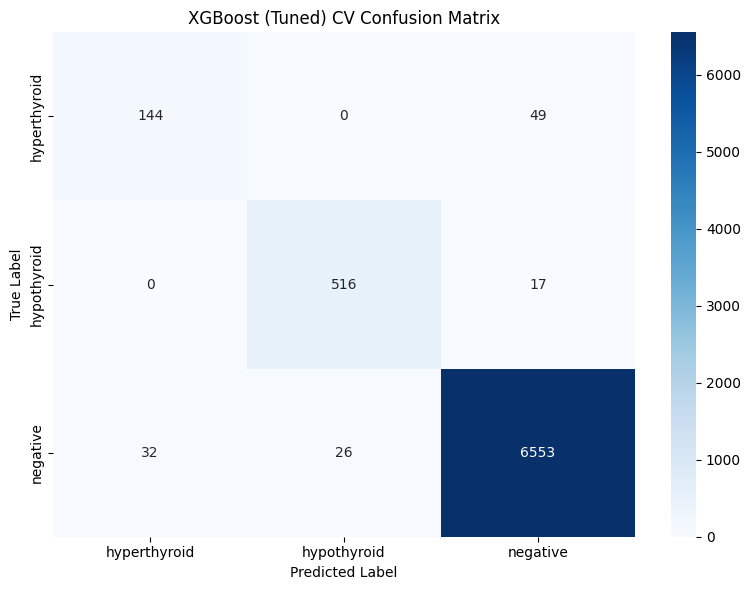

In [ ]:
cm = confusion_matrix(y_train_encoded, y_pred_cv)plt.figure(figsize=(8, 6))sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',            xticklabels=label_encoder.classes_,            yticklabels=label_encoder.classes_)plt.title('XGBoost (Tuned) CV Confusion Matrix')plt.ylabel('True Label')plt.xlabel('Predicted Label')plt.tight_layout()plt.show()

## Why the Scorer Alone Doesn't Improve Recall

The 0.75 recall for hyperthyroid is not acceptable — we are faltante 25% of hyperthyroid patients.The problem is that the F2 scorer only controls **which modelo wins** in the cross-validación outer bucle. It does nothing to the XGBoost *entrenamiento objective* inside each fold. XGBoost still fits each tree by minimising **unweighted** `mlogloss`, where a misclassified hyperthyroid patient counts exactly the same as a misclassified negative patient — despite the ~33:1 clase imbalance.The fix is to inject **clase weights** directly into the entrenamiento objective, so XGBoost pays more for minority-clase errors during tree construction.

## clase-Weighted entrenamiento

`sklearn.utils.compute_sample_weight('balanced', y)` computes per-sample weights inversely proportional to clase frequency. Passing them as `sample_weight` to XGBoost's `fit()` método makes each sample's contribution to the pérdida proportional to its weight — directly equivalent to `CrossEntropyLoss(weight=class_weights)` in the red neuronal (notebook 05).sklearn handles cross-validación correctly: for each fold only the entrenamiento-fold subset of `sample_weights` is passed to `fit()`, so there is **no Datos leakage**.

In [ ]:
from sklearn.utils import compute_sample_weight# Per-sample weights inversely proportional to clase frequencysample_weights = compute_sample_weight('balanced', y_train_encoded)pipeline_xgb_weighted = Pipeline([    ('preprocessor', get_native_nan_pipeline()),    ('classifier', XGBClassifier(        n_estimators=100,        learning_rate=0.1,        max_depth=6,        random_state=42,        n_jobs=-1,        eval_metric='mlogloss'    ))])scores_weighted = cross_val_score(    pipeline_xgb_weighted, X_train, y_train_encoded,    cv=stratified_cv,    scoring=thyroid_scorer,    params={'classifier__sample_weight': sample_weights})print("Weighted XGBoost - Thyroid Disease F2 Score")print(f"  Per-fold scores: {scores_weighted.round(3)}")print(f"  Mean: {scores_weighted.mean():.3f} (+/- {scores_weighted.std() * 2:.3f})")

Weighted XGBoost - Thyroid Disease F2 Score
  Per-fold scores: [0.896 0.861 0.926 0.887 0.914]
  Mean: 0.897 (+/- 0.045)


In [ ]:
random_search_weighted = RandomizedSearchCV(    pipeline_xgb_weighted,    param_distributions,    n_iter=20,    cv=stratified_cv,    scoring=thyroid_scorer,    random_state=42,    n_jobs=-1,    verbose=1)random_search_weighted.fit(    X_train, y_train_encoded,    classifier__sample_weight=sample_weights)print(f"Best Thyroid Disease F2 Score: {random_search_weighted.best_score_:.3f}")print("Best parameters:")for param, value in random_search_weighted.best_params_.items():    print(f"  {param}: {value}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Thyroid Disease F2 Score: 0.905
Best parameters:
  classifier__colsample_bytree: 0.786705157299192
  classifier__learning_rate: 0.25938271795353296
  classifier__max_depth: 9
  classifier__n_estimators: 70
  classifier__subsample: 0.7801997007878172


In [ ]:
best_xgb_weighted = random_search_weighted.best_estimator_y_pred_weighted = cross_val_predict(    best_xgb_weighted, X_train, y_train_encoded, cv=5, n_jobs=-1,    params={'classifier__sample_weight': sample_weights})print("Weighted XGBoost - Cross-Validation Classification Report:")print(classification_report(    y_train_encoded, y_pred_weighted,    target_names=label_encoder.classes_,    zero_division=0))

Weighted XGBoost - Cross-Validation Classification Report:
              precision    recall  f1-score   support

hyperthyroid       0.76      0.86      0.81       193
 hypothyroid       0.94      0.98      0.96       533
    negative       0.99      0.99      0.99      6611

    accuracy                           0.98      7337
   macro avg       0.90      0.94      0.92      7337
weighted avg       0.98      0.98      0.98      7337



## Final Comparison

We now compare the two XGBoost variants (unweighted vs. clase-weighted) on disease-clase recall and precision.

In [ ]:
import pandas as pdfrom sklearn.metrics import classification_report as cr_fncr_unweighted = cr_fn(y_train_encoded, y_pred_cv, target_names=label_encoder.classes_, zero_division=0, output_dict=True)cr_weighted = cr_fn(y_train_encoded, y_pred_weighted, target_names=label_encoder.classes_, zero_division=0, output_dict=True)rows = []for label in ['hyperthyroid', 'hypothyroid']:    for variant, cr in [        ('Tuned XGBoost (unweighted)', cr_unweighted),        ('Weighted XGBoost', cr_weighted),    ]:        rows.append({            'Class': label,            'Variant': variant,            'Precision': f"{cr[label]['precision']:.3f}",            'Recall': f"{cr[label]['recall']:.3f}",            'F1': f"{cr[label]['f1-score']:.3f}",            'Support': int(cr[label]['support']),        })comparison_df = pd.DataFrame(rows).set_index(['Class', 'Variant'])display(comparison_df)

Precision Recall     F1  Support
Class        Variant                                                    
hyperthyroid Tuned XGBoost (unweighted)     0.818  0.746  0.780      193
             Weighted XGBoost               0.761  0.860  0.808      193
hypothyroid  Tuned XGBoost (unweighted)     0.952  0.968  0.960      533
             Weighted XGBoost               0.936  0.983  0.959      533

## Conclusions**Key findings:**- gradient boosting (XGBoost) achieves a strong baseline; Hiperparámetro tuning provides marginal additional gains- **Changing the evaluación scorer alone does not improve recall** — the scorer selects Hiperparámetros but does not change the entrenamiento objective; XGBoost still minimises unweighted `mlogloss`- **clase-weighted entrenamiento (`sample_weight`)** is the correct fix: it directly changes the pérdida landscape so XGBoost pays more for minority-clase errors during tree construction — equivalent to `CrossEntropyLoss(weight=...)` in the red neuronal (notebook 05)- The improvement in disease recall comes at the costo of some precision (more false positives); which trade-off is acceptable depends on clinical context — in this domain a downstream physician review is assumed Para unll positive predicciones